# TASK #1: UNDERSTAND THE PROBLEM STATEMENT AND BUSINESS CASE

![alt text](Operation_Department_Png/download.png)

![alt text](Operation_Department_Png/download_1.png)

![alt text](Operation_Department_Png/download_2.png)

# TASK #2: IMPORT LIBRARIES AND DATASET

In [2]:
# This is a custom dataset that contains covid-19 x-ray images, viral pneumonia x-ray images, bacterial pneumonia x-ray iamges and normal person x-ray images.
# Each class contains 133 images.
# Dataset Source:
# https://github.com/ieee8023/covid-chestxray-dataset
# https://www.kaggle.com/paultimothymooney/chest-xray-pneumonia


import os
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, optimizers
from tensorflow.keras.applications.resnet50 import ResNet50
from tensorflow.keras.layers import Input, Add, Dense, Activation, ZeroPadding2D, BatchNormalization, Flatten, Conv2D, AveragePooling2D, MaxPooling2D, Dropout
from tensorflow.keras.models import Model, load_model
from tensorflow.keras import backend as K
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint, LearningRateScheduler
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Specify training data directory
X_Ray_Directory = 'Dataset'

In [4]:
# List the folders in the directory
os.listdir(X_Ray_Directory)

['.DS_Store1', '0', '1', '2', '3']

In [5]:
# Use image generator to generate tensor images data and normalize them
# Use 20% of the data for cross-validation
image_generator = ImageDataGenerator(rescale=1./255, validation_split=0.2)

In [14]:
# Generate batches of 40 images
# Total number of images is 133 * 4 = 532 = 532 images
# Training is 428 (80%) and validation is 104 (20%)
train_generator = image_generator.flow_from_directory(directory=X_Ray_Directory, target_size=(256, 256), batch_size=40, shuffle=True, class_mode='categorical', subset='training')

Found 428 images belonging to 4 classes.


In [15]:
validation_generator = image_generator.flow_from_directory(directory=X_Ray_Directory, target_size=(256, 256), batch_size=40, shuffle=True, class_mode='categorical', subset='validation')

Found 104 images belonging to 4 classes.


In [16]:
# Generate a batch of 40 images and labels
train_images, train_labels = next(train_generator)

In [17]:
train_images.shape

(40, 256, 256, 3)

In [18]:
train_labels.shape

(40, 4)

In [19]:
train_labels

array([[0., 0., 1., 0.],
       [1., 0., 0., 0.],
       [0., 1., 0., 0.],
       [1., 0., 0., 0.],
       [0., 0., 0., 1.],
       [0., 0., 0., 1.],
       [0., 0., 1., 0.],
       [1., 0., 0., 0.],
       [0., 0., 1., 0.],
       [1., 0., 0., 0.],
       [0., 1., 0., 0.],
       [0., 0., 1., 0.],
       [0., 1., 0., 0.],
       [0., 0., 1., 0.],
       [0., 0., 1., 0.],
       [1., 0., 0., 0.],
       [0., 0., 0., 1.],
       [1., 0., 0., 0.],
       [0., 0., 1., 0.],
       [0., 0., 0., 1.],
       [1., 0., 0., 0.],
       [0., 0., 1., 0.],
       [0., 0., 1., 0.],
       [0., 0., 1., 0.],
       [0., 0., 1., 0.],
       [0., 0., 0., 1.],
       [0., 1., 0., 0.],
       [0., 0., 0., 1.],
       [0., 0., 0., 1.],
       [0., 0., 1., 0.],
       [0., 1., 0., 0.],
       [1., 0., 0., 0.],
       [0., 0., 0., 1.],
       [0., 0., 0., 1.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 0., 0., 1.],
       [0., 0., 1., 0.],
       [0., 0., 0., 1.],
       [0., 1., 0., 0.]],

In [20]:
# labels Translator
label_names = {0: 'Covid19', 1:'Normal', 2:'Viral Pneumonia', 3:'Bacterial Pneumonia'}

# TASK #3: VISUALIZE DATASET 

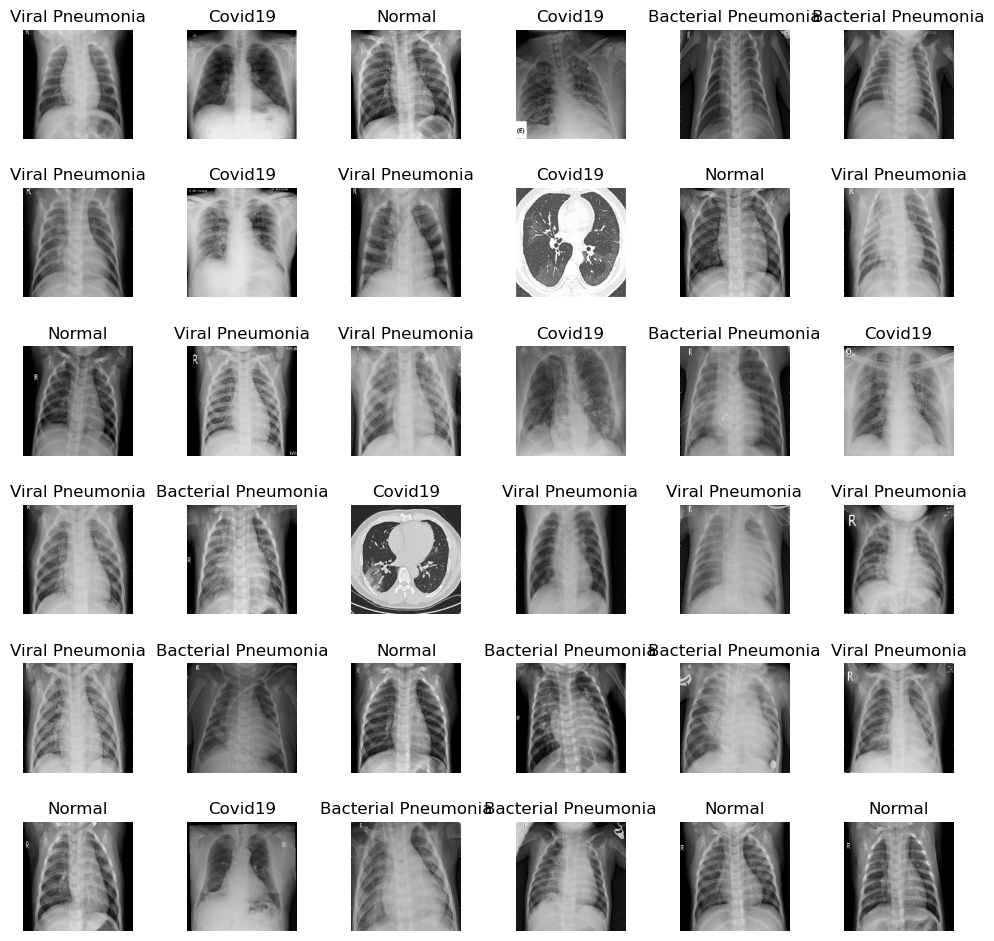

In [ ]:
L = 6
W = 6

fig, axes = plt.subplots(L, W, figsize=(12,12))
axes = axes.ravel()

for i in np.arange(0, L * W):
    axes[i].imshow(train_images[i])
    axes[i].set_title(label_names[np.argmax(train_labels[i])])
    axes[i].axis('off')

plt.subplots_adjust(wspace=0.5)

# TASK #4: IMPORT MODEL WITH PRETRAINED WEIGHTS 

In [23]:
basemodel = ResNet50(weights= 'imagenet', include_top=False, input_tensor=Input(shape=(256,256,3)))

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 16s 0us/step


In [24]:
basemodel.summary()

Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 262, 262,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 128, 128,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 128, 128,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 128, 128,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 130, 130,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 64, 64,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 64, 64,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 64, 64,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 64, 64,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 64, 64,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 64, 64,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 64, 64,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 64, 64,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 64, 64,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 64, 64,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 64, 64,    │      1,024 │ conv2_block1_3_c

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 23,534,592 (89.78 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [25]:
# freezing layers in the model
for layer in basemodel.layers[:-4]:
    layer.trainable = False

# TASK #5: BUILD AND TRAIN DEEP LEARNING MODEL

In [26]:
headmodel = basemodel.output
headmodel = AveragePooling2D(pool_size=(4,4))(headmodel)
headmodel = Flatten(name= 'flatten')(headmodel)
headmodel = Dense(256, activation='relu')(headmodel)
headmodel = Dropout(0.3)(headmodel)
headmodel = Dense(256, activation='relu')(headmodel)
headmodel = Dropout(0.3)(headmodel)
headmodel = Dense(4, activation='softmax')(headmodel)

In [27]:
model = Model(inputs = basemodel.input, outputs = headmodel)

In [28]:
model.compile(loss='categorical_crossentropy', optimizer= optimizers.RMSprop(learning_rate=1e-4), metrics=[ 'accuracy'])

In [29]:
# using early stopping to exist training when validation loss is not decreasing after certain number of epochs (patience)
earlystopping = EarlyStopping(monitor= 'val_loss', mode= 'min', patience= 20)

# save the best model with lower vaidation loss
checkpointer = ModelCheckpoint(filepath= 'weights.h5', verbose= 1, save_best_only=True, monitor='val_loss', mode='min')

In [30]:
train_generator = image_generator.flow_from_directory(directory= X_Ray_Directory, target_size=(256, 256), batch_size=40, shuffle=True, class_mode='categorical', subset='training')


validation_generator = image_generator.flow_from_directory(directory= X_Ray_Directory, target_size=(256, 256), batch_size=40, shuffle=True, class_mode='categorical', subset='validation')

Found 428 images belonging to 4 classes.
Found 104 images belonging to 4 classes.


In [32]:

history = model.fit(train_generator, epochs = 25, validation_data= validation_generator, callbacks = [checkpointer, earlystopping])

Epoch 1/25
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6769 - loss: 0.7993
Epoch 1: val_loss did not improve from 1.32723
11/11 ━━━━━━━━━━━━━━━━━━━━ 47s 4s/step - accuracy: 0.6706 - loss: 0.7721 - val_accuracy: 0.2885 - val_loss: 1.3694
Epoch 2/25
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7057 - loss: 0.7663
Epoch 2: val_loss did not improve from 1.32723
11/11 ━━━━━━━━━━━━━━━━━━━━ 49s 4s/step - accuracy: 0.6706 - loss: 0.8143 - val_accuracy: 0.2981 - val_loss: 1.4001
Epoch 3/25
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7138 - loss: 0.7597
Epoch 3: val_loss did not improve from 1.32723
11/11 ━━━━━━━━━━━━━━━━━━━━ 47s 4s/step - accuracy: 0.7103 - loss: 0.7644 - val_accuracy: 0.2885 - val_loss: 1.3782
Epoch 4/25
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7034 - loss: 0.7545
Epoch 4: val_loss did not improve from 1.32723
11/11 ━━━━━━━━━━━━━━━━━━━━ 48s 4s/step - accuracy: 0.6916 - loss: 0.7841 - val_accuracy: 0.3654 - val_loss: 1.5033
Epoch 5/25
11/11 ━━━


Epoch 5: finished saving model to weights.h5
11/11 ━━━━━━━━━━━━━━━━━━━━ 50s 5s/step - accuracy: 0.7266 - loss: 0.7061 - val_accuracy: 0.3750 - val_loss: 1.2503
Epoch 6/25
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6763 - loss: 0.7547
Epoch 6: val_loss did not improve from 1.25028
11/11 ━━━━━━━━━━━━━━━━━━━━ 49s 4s/step - accuracy: 0.6682 - loss: 0.7637 - val_accuracy: 0.3654 - val_loss: 1.2675
Epoch 7/25
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7369 - loss: 0.6497
Epoch 7: val_loss did not improve from 1.25028
11/11 ━━━━━━━━━━━━━━━━━━━━ 47s 4s/step - accuracy: 0.7523 - loss: 0.6517 - val_accuracy: 0.3365 - val_loss: 1.4352
Epoch 8/25
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7350 - loss: 0.6566
Epoch 8: val_loss improved from 1.25028 to 1.14333, saving model to weights.h5



Epoch 8: finished saving model to weights.h5
11/11 ━━━━━━━━━━━━━━━━━━━━ 48s 4s/step - accuracy: 0.7220 - loss: 0.6985 - val_accuracy: 0.3558 - val_loss: 1.1433
Epoch 9/25
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7270 - loss: 0.6944
Epoch 9: val_loss did not improve from 1.14333
11/11 ━━━━━━━━━━━━━━━━━━━━ 48s 4s/step - accuracy: 0.7547 - loss: 0.6524 - val_accuracy: 0.2885 - val_loss: 1.4259
Epoch 10/25
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7480 - loss: 0.6256
Epoch 10: val_loss did not improve from 1.14333
11/11 ━━━━━━━━━━━━━━━━━━━━ 45s 4s/step - accuracy: 0.7477 - loss: 0.6437 - val_accuracy: 0.3558 - val_loss: 1.2519
Epoch 11/25
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7993 - loss: 0.5614
Epoch 11: val_loss did not improve from 1.14333
11/11 ━━━━━━━━━━━━━━━━━━━━ 56s 5s/step - accuracy: 0.7804 - loss: 0.6100 - val_accuracy: 0.5577 - val_loss: 1.1660
Epoch 12/25
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7742 - loss: 0.6571
Epoch 12: val_lo


Epoch 13: finished saving model to weights.h5
11/11 ━━━━━━━━━━━━━━━━━━━━ 47s 4s/step - accuracy: 0.7430 - loss: 0.6552 - val_accuracy: 0.3846 - val_loss: 1.0870
Epoch 14/25
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8117 - loss: 0.5939
Epoch 14: val_loss did not improve from 1.08699
11/11 ━━━━━━━━━━━━━━━━━━━━ 47s 4s/step - accuracy: 0.8014 - loss: 0.5739 - val_accuracy: 0.3077 - val_loss: 1.4386
Epoch 15/25
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7826 - loss: 0.5872
Epoch 15: val_loss did not improve from 1.08699
11/11 ━━━━━━━━━━━━━━━━━━━━ 43s 4s/step - accuracy: 0.8061 - loss: 0.5573 - val_accuracy: 0.3077 - val_loss: 1.4632
Epoch 16/25
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7571 - loss: 0.5939
Epoch 16: val_loss improved from 1.08699 to 0.93282, saving model to weights.h5



Epoch 16: finished saving model to weights.h5
11/11 ━━━━━━━━━━━━━━━━━━━━ 43s 4s/step - accuracy: 0.7687 - loss: 0.6036 - val_accuracy: 0.6250 - val_loss: 0.9328
Epoch 17/25
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7993 - loss: 0.5645
Epoch 17: val_loss did not improve from 0.93282
11/11 ━━━━━━━━━━━━━━━━━━━━ 47s 4s/step - accuracy: 0.7780 - loss: 0.5936 - val_accuracy: 0.5096 - val_loss: 1.0955
Epoch 18/25
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8359 - loss: 0.5002
Epoch 18: val_loss improved from 0.93282 to 0.92704, saving model to weights.h5



Epoch 18: finished saving model to weights.h5
11/11 ━━━━━━━━━━━━━━━━━━━━ 48s 4s/step - accuracy: 0.8084 - loss: 0.5190 - val_accuracy: 0.5769 - val_loss: 0.9270
Epoch 19/25
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7980 - loss: 0.5439
Epoch 19: val_loss improved from 0.92704 to 0.84551, saving model to weights.h5



Epoch 19: finished saving model to weights.h5
11/11 ━━━━━━━━━━━━━━━━━━━━ 48s 4s/step - accuracy: 0.8037 - loss: 0.5255 - val_accuracy: 0.6346 - val_loss: 0.8455
Epoch 20/25
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8176 - loss: 0.5505
Epoch 20: val_loss did not improve from 0.84551
11/11 ━━━━━━━━━━━━━━━━━━━━ 48s 4s/step - accuracy: 0.8154 - loss: 0.5459 - val_accuracy: 0.6250 - val_loss: 0.8630
Epoch 21/25
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8148 - loss: 0.4337
Epoch 21: val_loss did not improve from 0.84551
11/11 ━━━━━━━━━━━━━━━━━━━━ 48s 4s/step - accuracy: 0.8107 - loss: 0.4845 - val_accuracy: 0.4712 - val_loss: 1.1205
Epoch 22/25
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8320 - loss: 0.5481
Epoch 22: val_loss did not improve from 0.84551
11/11 ━━━━━━━━━━━━━━━━━━━━ 47s 4s/step - accuracy: 0.8248 - loss: 0.4969 - val_accuracy: 0.6154 - val_loss: 0.9000
Epoch 23/25
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7667 - loss: 0.5763
Epoch 23: val


Epoch 24: finished saving model to weights.h5
11/11 ━━━━━━━━━━━━━━━━━━━━ 48s 4s/step - accuracy: 0.8248 - loss: 0.4722 - val_accuracy: 0.7019 - val_loss: 0.7526
Epoch 25/25
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7842 - loss: 0.5860
Epoch 25: val_loss did not improve from 0.75262
11/11 ━━━━━━━━━━━━━━━━━━━━ 48s 4s/step - accuracy: 0.8271 - loss: 0.4861 - val_accuracy: 0.6058 - val_loss: 0.9532


# TASK #6: EVALUATE TRAINED DEEP LEARNING MODEL

In [33]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

Text(0, 0.5, 'Training accuracy and loss')

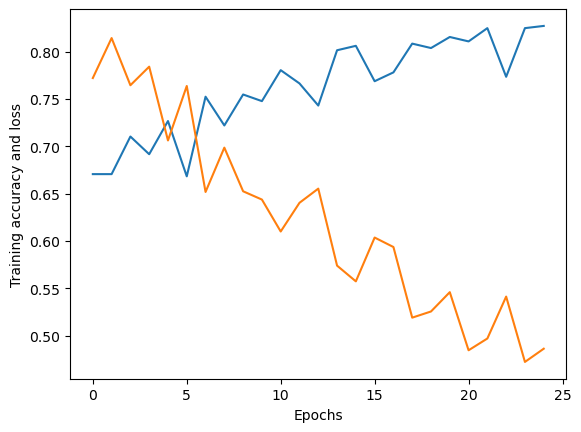

In [34]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['loss'])
plt.xlabel('Epochs')
plt.ylabel('Training accuracy and loss')

Text(0, 0.5, 'Validation loss')

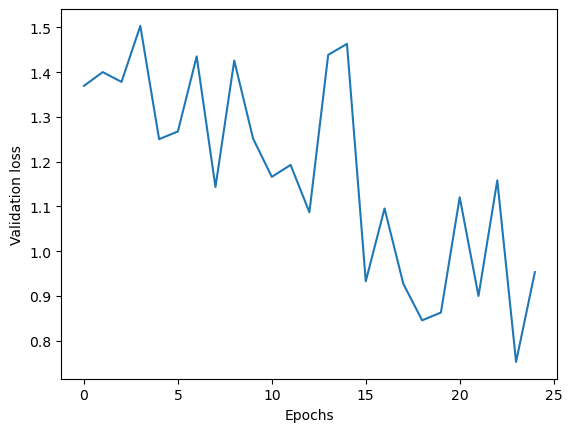

In [35]:
plt.plot(history.history['val_loss'])
plt.xlabel('Epochs')
plt.ylabel('Validation loss')

Text(0, 0.5, 'Validation accuracy')

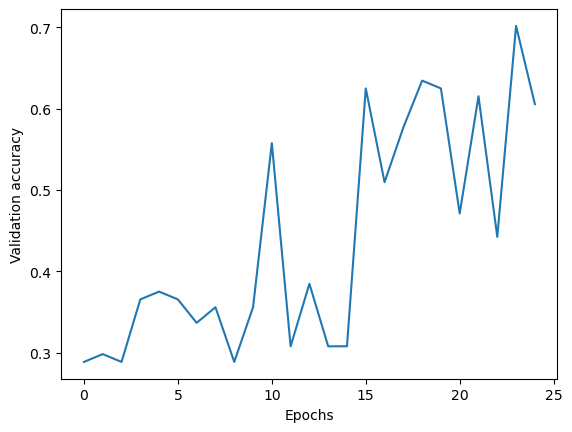

In [36]:
plt.plot(history.history['val_accuracy'])
plt.xlabel('Epochs')
plt.ylabel('Validation accuracy')

In [37]:
test_directory = 'Test'

In [38]:
test_gen = ImageDataGenerator(rescale=1./255)

test_generator = test_gen.flow_from_directory(directory= test_directory, target_size=(256, 256), batch_size=40, shuffle=False, class_mode='categorical')

evaluate = model.evaluate(test_generator, verbose=1)

print(f"Accuracy Test: {evaluate[1]}")

Found 40 images belonging to 4 classes.
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.4500 - loss: 1.0269
Accuracy Test: 0.44999998807907104


In [39]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

prediction = []
original = []
image = []

for i in range(len(os.listdir(test_directory))):
    class_dir = os.path.join(test_directory, str(i))
    
    # Check if the directory exists before proceeding
    if os.path.isdir(class_dir):
        for item in os.listdir(class_dir):
            img = cv2.imread(os.path.join(class_dir, item))
            img = cv2.resize(img, (256, 256))
            image.append(img)
            img = img / 255
            img = img.reshape(-1, 256, 256, 3)
            predict = model.predict(img)
            predict = np.argmax(predict)
            prediction.append(predict)
            original.append(i)
    else:
        print(f"Directory {class_dir} is missing or empty.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

In [40]:
len(original)

40

In [41]:
score = accuracy_score(original, prediction)
print(f"Test Accuracy: {score}")

Test Accuracy: 0.45


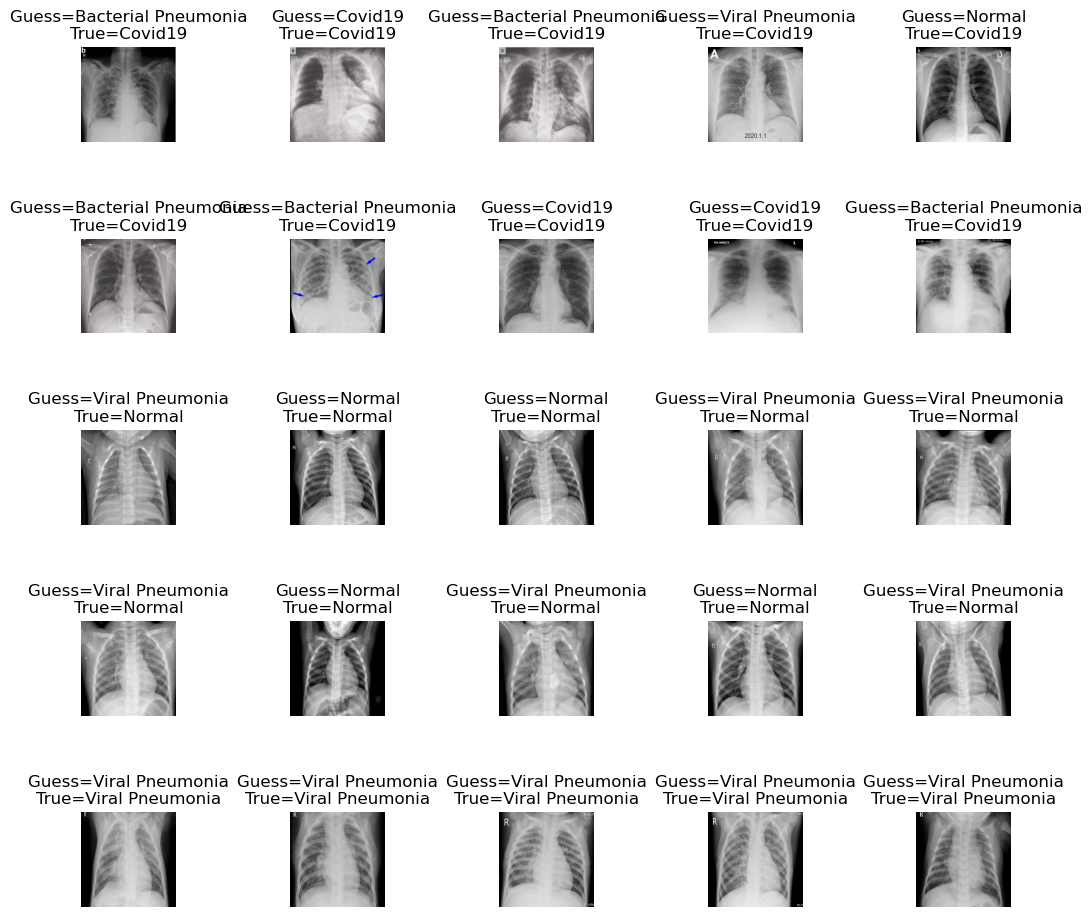

In [42]:
L = 5
W = 5

fig, axes = plt.subplots(L, W, figsize = (12, 12))
axes = axes.ravel()

for i in np.arange(0, L*W):
    axes[i].imshow(image[i])
    axes[i].set_title(f"Guess={label_names[prediction[i]]}\nTrue={label_names[original[i]]}")
    axes[i].axis('off')

plt.subplots_adjust(wspace = 1.2)

In [43]:
print(classification_report(np.asarray(original), np.asarray(prediction)))

              precision    recall  f1-score   support

           0       1.00      0.30      0.46        10
           1       0.50      0.40      0.44        10
           2       0.35      0.60      0.44        10
           3       0.42      0.50      0.45        10

    accuracy                           0.45        40
   macro avg       0.57      0.45      0.45        40
weighted avg       0.57      0.45      0.45        40



Text(0.5, 1.0, 'Confusion_matrix')

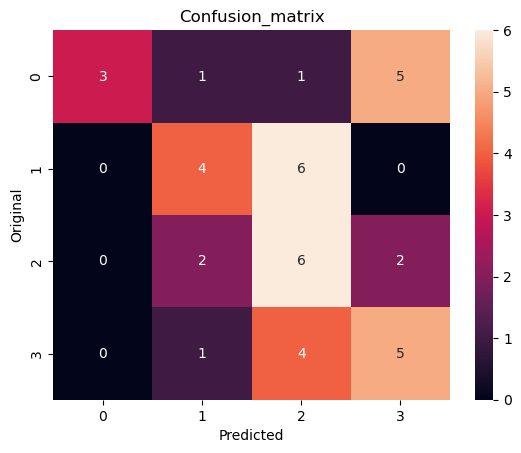

In [44]:
cm = confusion_matrix(np.asarray(original), np.asarray(prediction))
ax = plt.subplot()
sns.heatmap(cm, annot = True, ax = ax)

ax.set_xlabel('Predicted')
ax.set_ylabel('Original')
ax.set_title('Confusion_matrix')